# Settings

In [1]:
alpha = 0.05 

In [2]:
def underline(txt: str) -> str:
    """Return *txt* underlined for terminals that support ANSI codes."""
    return f"\033[4m{txt}\033[0m"

def bold(txt: str) -> str:
    """Return *txt* wrapped in the ANSI code for bold (bright) text."""
    return f"\033[1m{txt}\033[0m"

Loading the Study Results into a Dataframe: 

In [3]:
from Study import participants
from HelperFunctions.get_data import get_data

df = get_data(participants=participants, task_ids=[i for i in range(1,18)])
df["id"] = df["id"].apply(lambda x: x.replace("task_", "")).astype(int)

Does not know what IF is, question skipped after trying to figure it out skipped
Skipped, too complicated skipped
Skipped, too complicated skipped
Skipped, doesn't know max skipped
Participant found the -1 confusing, skipped skipped
Did not understand, skipped skipped
Participant was overwhelmed, skipped the question skipped
Participant did not understand, skipped  skipped


-> the data frame includes the columns: 
- "id" for the task id
- "participant" for the participants IDs
- the measured "TTU"
- the measured "DOU"
- information about the tasks content 

# 1. DOU

In [4]:
df_notone = df[df["DOU"] != 1.0]
print(f"❗ Es gibt nur {df_notone.shape[0]} von {df.shape[0]} DOU-Werten, die nicht 1.0 sind.")
print(f"→ Das sind {100 * (1 - df_notone.shape[0] / df.shape[0]):.1f}% = 1.0")

❗ Es gibt nur 110 von 357 DOU-Werten, die nicht 1.0 sind.
→ Das sind 69.2% = 1.0


# 2. TTU (task-wise) 

In [5]:
import numpy as np
import pandas as pd
import pingouin as pg
from statsmodels.stats.multitest import multipletests

def testing_task(df:pd.Dataframe, task_id:int): 
    df_task = df[df["id"] == task_id].copy()

    assert df_task["group"].nunique() == 3
    assert df_task.groupby("group").size().min() >= 2

    df_task["TTU_log"] = np.log(df_task["TTU"])

    # ANOVA mit log(TTU)
    anova_result = pg.anova(data=df_task, dv="TTU_log", between="group", detailed=True)
    p_anova = anova_result["p_unc"].iloc[0]
    anova_sig = "Significant" if p_anova < alpha else "Not significant"

    # Kruskal-Wallis mit Original-TTU
    kruskal_result = pg.kruskal(data=df_task, dv="TTU", between="group")
    p_kruskal = kruskal_result["p_unc"].iloc[0]
    kruskal_sig = "Significant" if p_kruskal < alpha else "Not significant"

    # Statistiken
    group_stats = df_task.groupby("group")["TTU"].agg(["mean", "median", "std", "count"]).round(3)
    mean_orig = group_stats["mean"].to_dict()
    median_orig = group_stats["median"].to_dict()
    std_orig = group_stats["std"].to_dict()

    print(f"\nTask {task_id:2d}:")
    print(f"   → ANOVA (log): p = {p_anova:.4f} ({anova_sig})")
    print(f"   → Kruskal-Wallis: p = {p_kruskal:.4f} ({kruskal_sig})")
    print(f"   → Mean (TTU): {mean_orig}")
    print(f"   → Mediane (TTU): {median_orig}")
    print(f"   → Std-Abw. (TTU): {std_orig}")

    return {
        "task_id": task_id,
        "p_anova": p_anova,
        "p_kruskal": p_kruskal,
        "anova_sig": anova_sig,
        "kruskal_sig": kruskal_sig,
        "median_TTU": median_orig,
        "mean_TTU": mean_orig,
        "std_TTU": std_orig
    }

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def box_plot_per_task(df:pd.Dataframe, task_id:int):
    df_task = df[df["id"] == task_id]
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_task, x="group", y="TTU", color="lightblue")
    sns.stripplot(data=df_task, x="group", y="TTU", color="red", jitter=True)
    plt.title(f"Task {task_id}: TTU (Original) nach Gruppen")
    plt.ylabel("Bearbeitungszeit (s)")
    plt.show()

def violin_plot_per_task(df:pd.Dataframe, task_id:int):
    df_task = df[df["id"] == task_id]
    sns.violinplot(data=df_task, x="group", y="TTU")
    plt.title(f"Task {task_id}: Streuung der TTU nach Gruppen")
    plt.ylabel("Bearbeitungszeit (s)")
    plt.show()

In [7]:
results = []

for task_id in range(1,18): 
    results.append( 
        testing_task(df=df, task_id=task_id)
    )


Task  1:
   → ANOVA (log): p = 0.5340 (Not significant)
   → Kruskal-Wallis: p = 0.4850 (Not significant)
   → Mean (TTU): {'Dynamic sketch construction': 32.0, 'Formula construction': 32.571, 'Static sketch construction': 25.714}
   → Mediane (TTU): {'Dynamic sketch construction': 26.0, 'Formula construction': 23.0, 'Static sketch construction': 24.0}
   → Std-Abw. (TTU): {'Dynamic sketch construction': 14.376, 'Formula construction': 26.974, 'Static sketch construction': 17.114}

Task  2:
   → ANOVA (log): p = 0.0345 (Significant)
   → Kruskal-Wallis: p = 0.0685 (Not significant)
   → Mean (TTU): {'Dynamic sketch construction': 22.571, 'Formula construction': 18.714, 'Static sketch construction': 14.0}
   → Mediane (TTU): {'Dynamic sketch construction': 21.0, 'Formula construction': 16.0, 'Static sketch construction': 14.0}
   → Std-Abw. (TTU): {'Dynamic sketch construction': 6.949, 'Formula construction': 5.469, 'Static sketch construction': 6.298}

Task  3:
   → ANOVA (log): p = 0

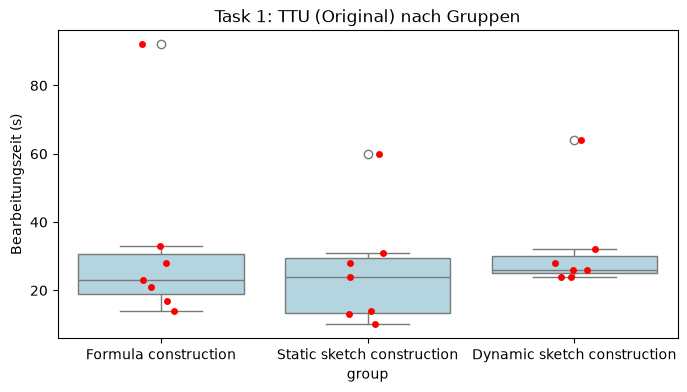

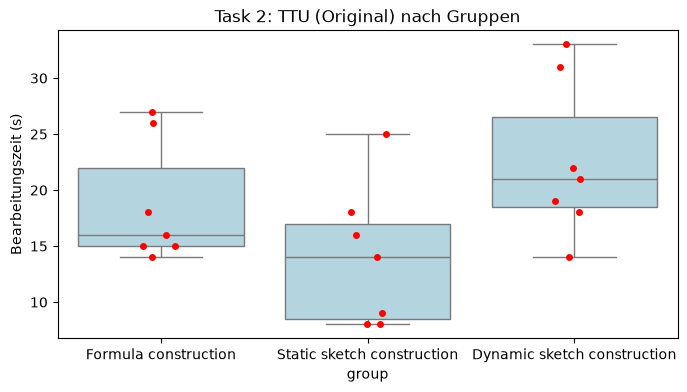

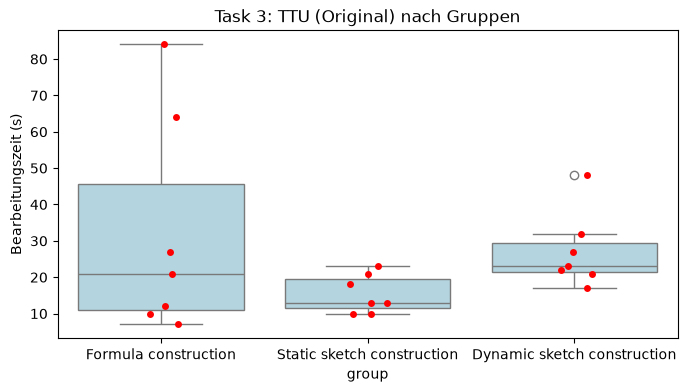

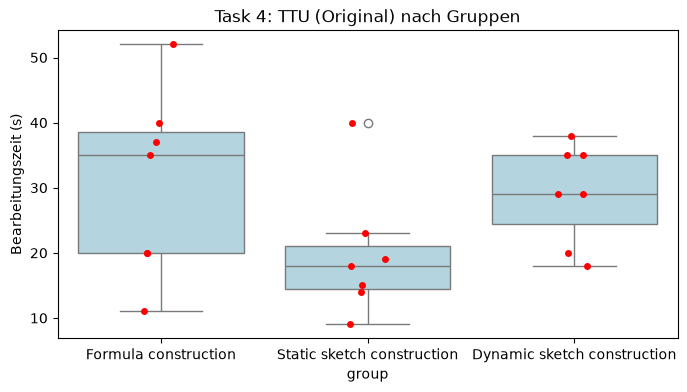

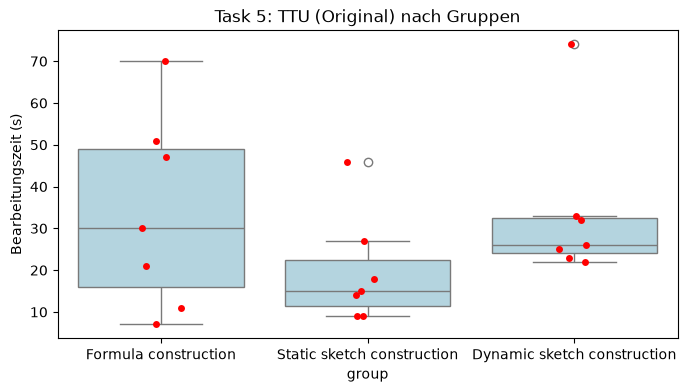

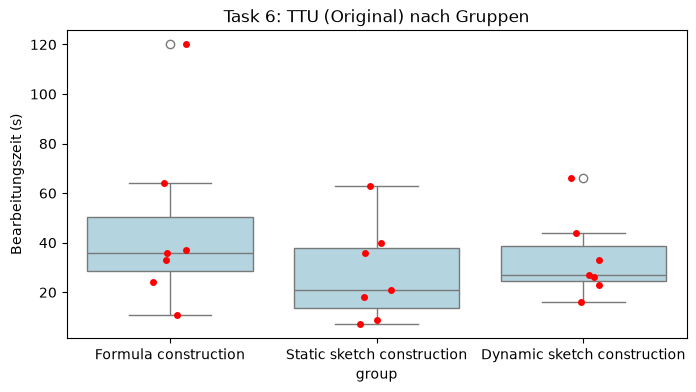

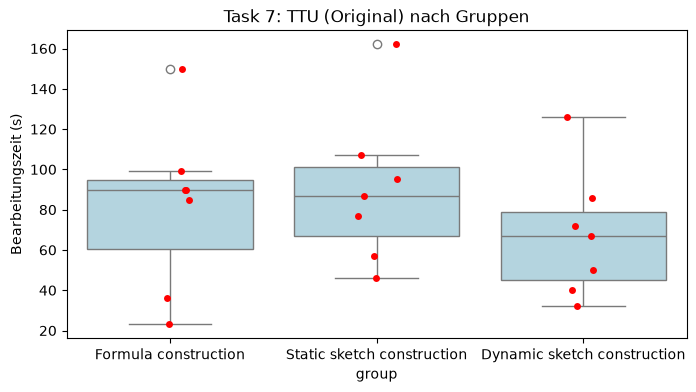

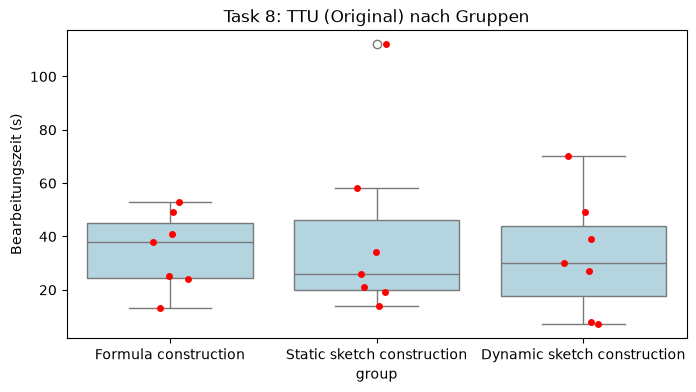

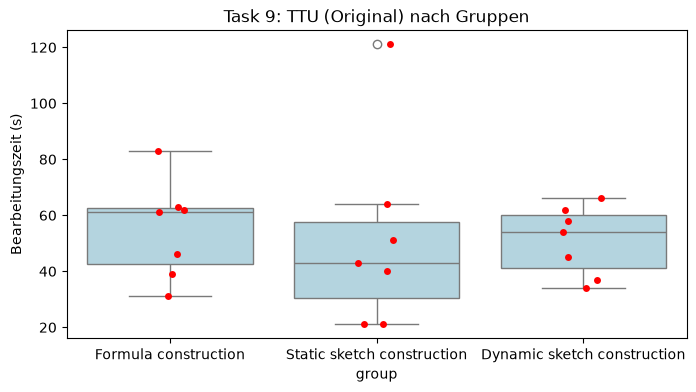

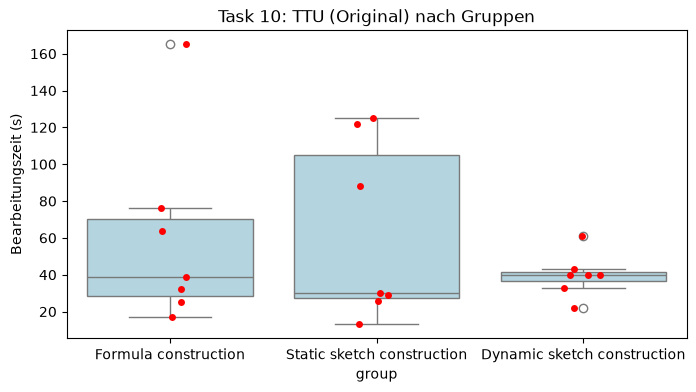

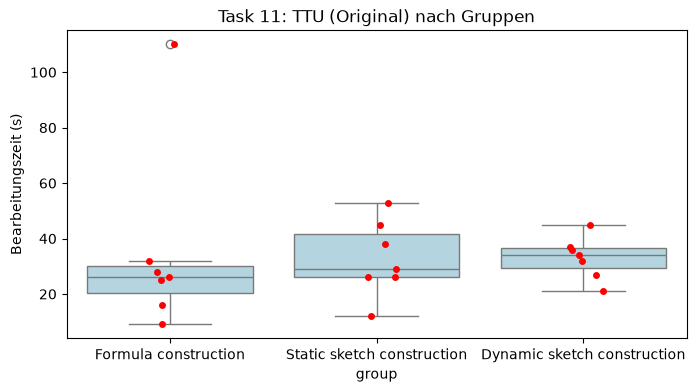

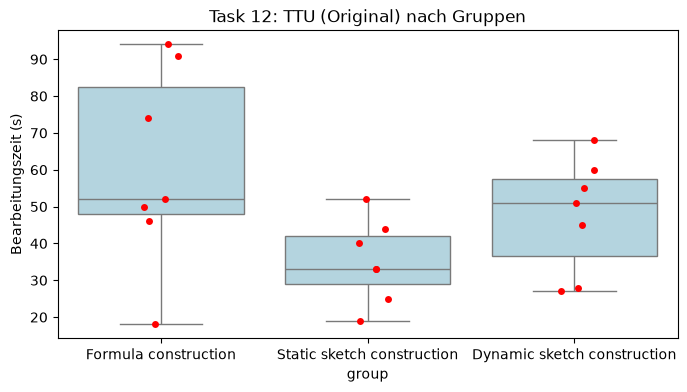

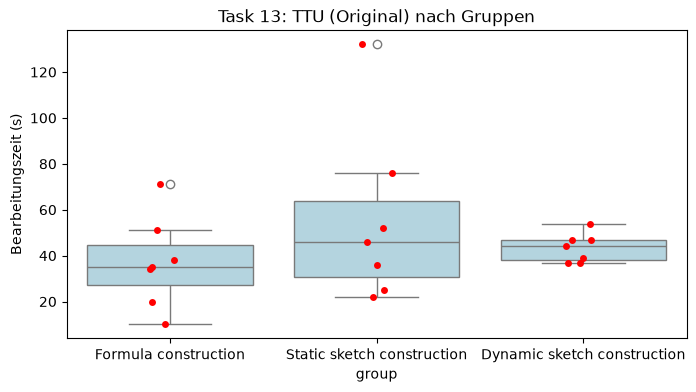

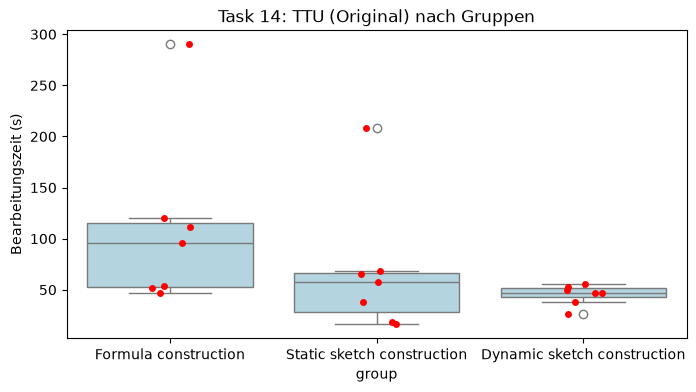

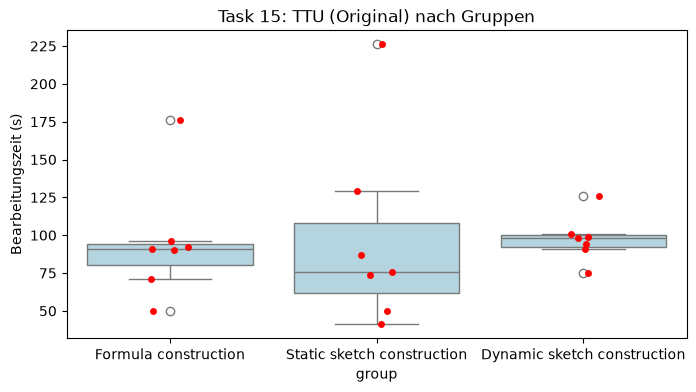

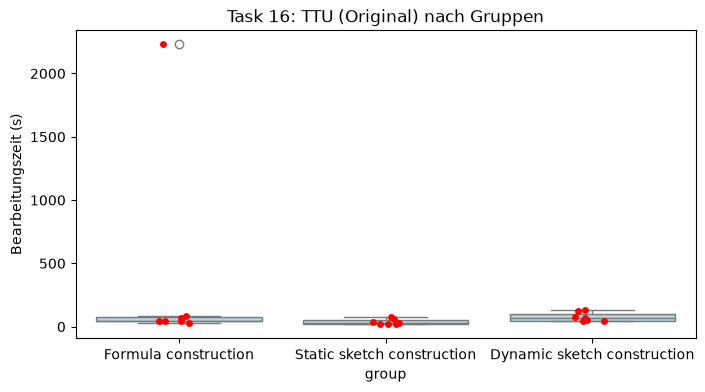

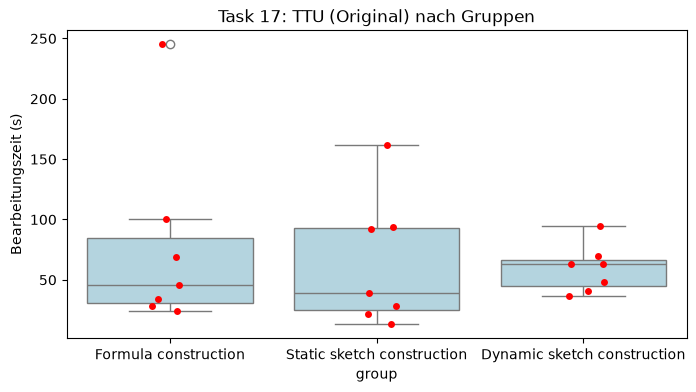

In [8]:
for task_id in range(1,18): 
    box_plot_per_task(df=df, task_id=task_id)

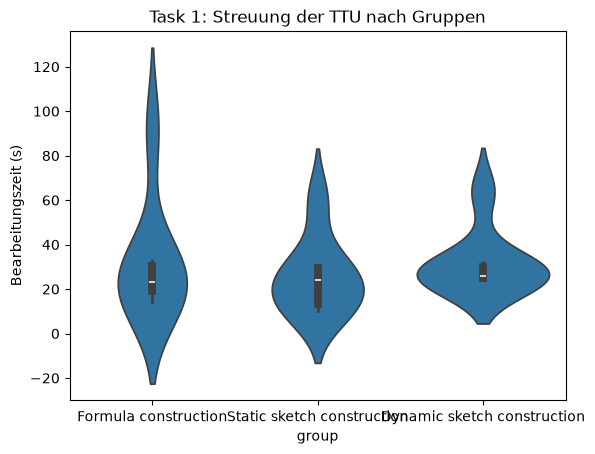

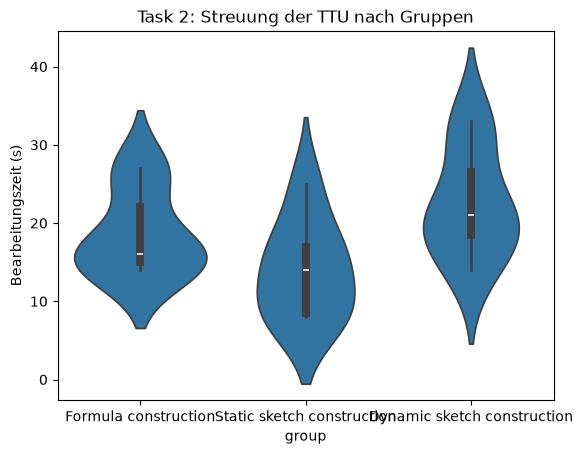

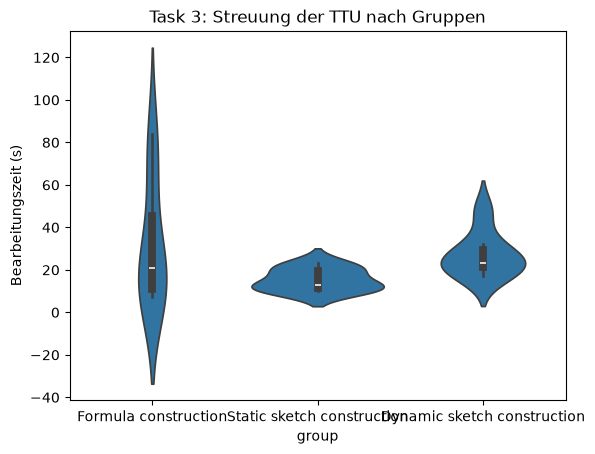

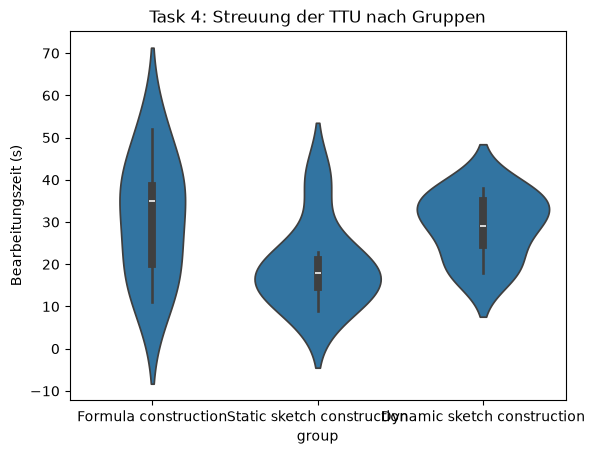

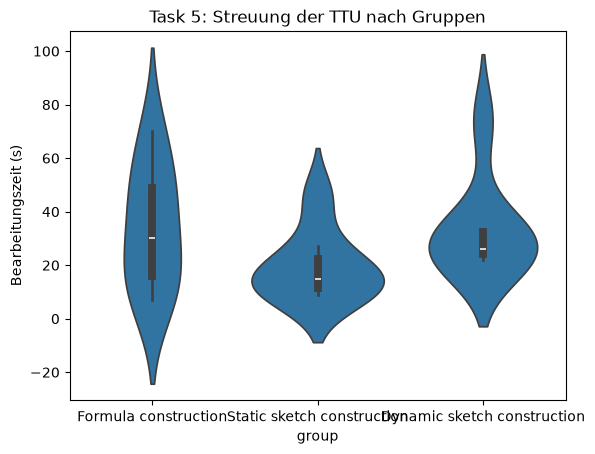

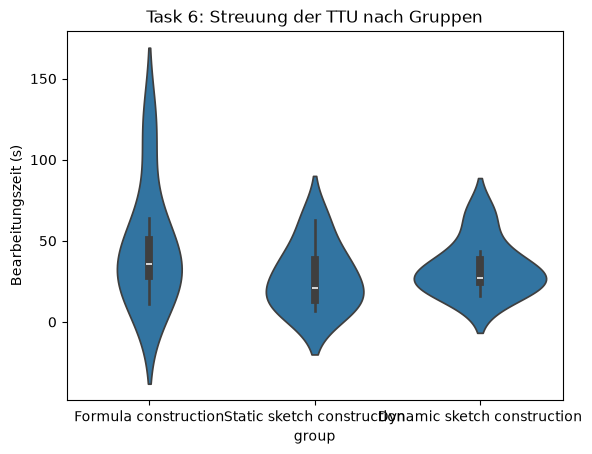

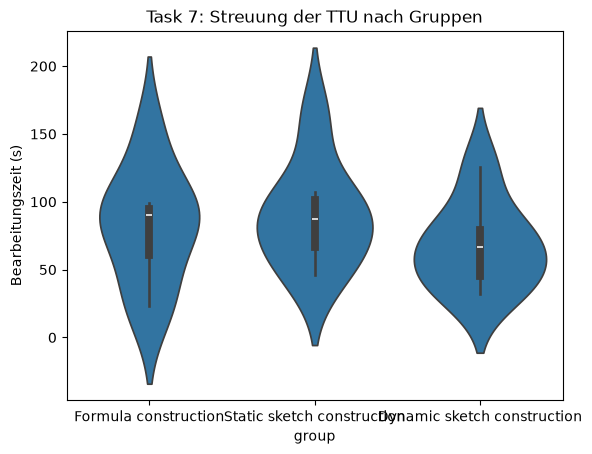

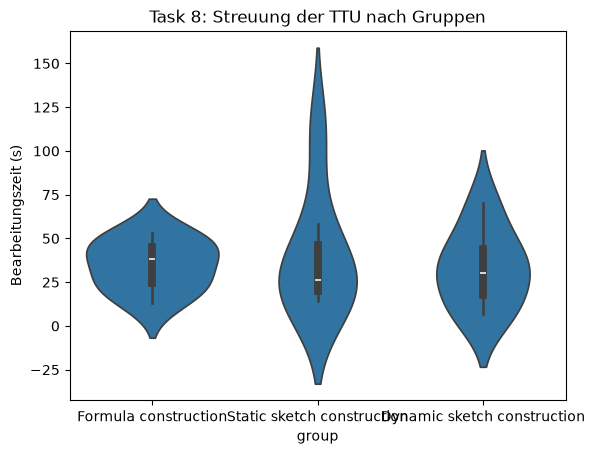

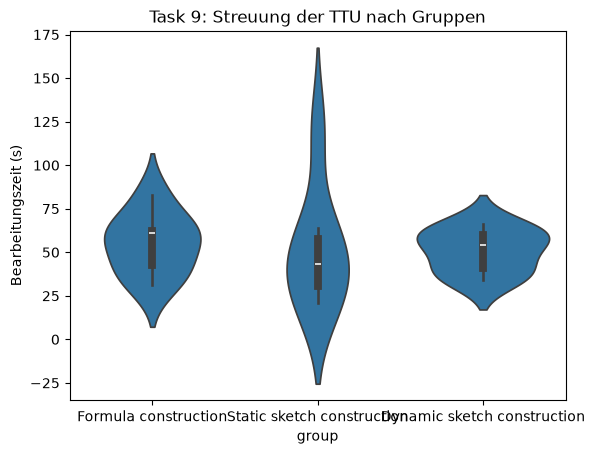

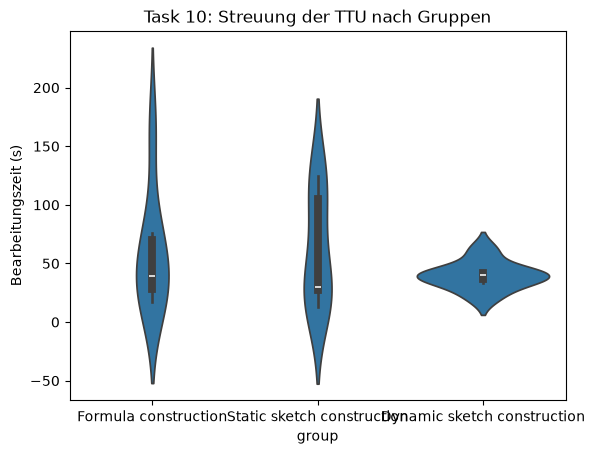

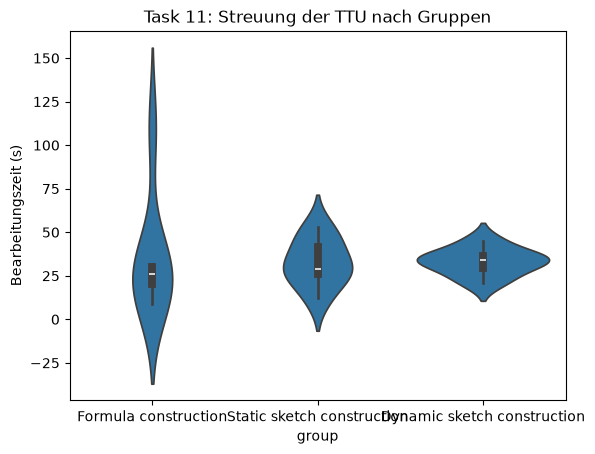

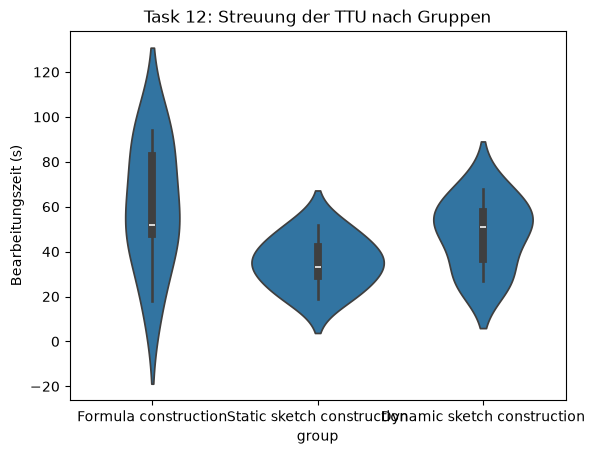

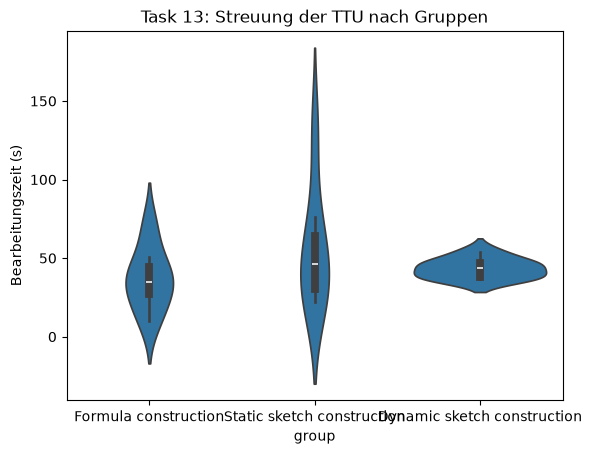

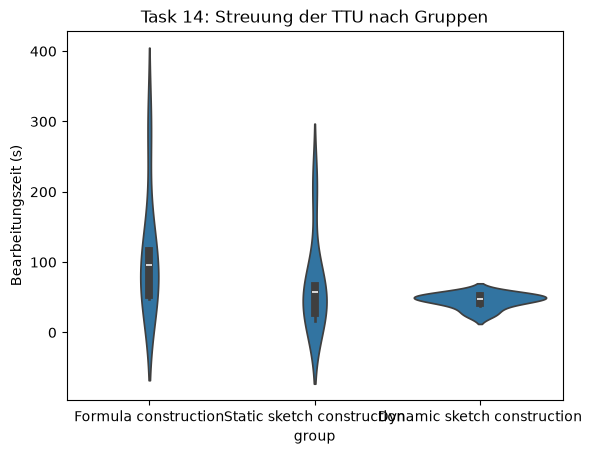

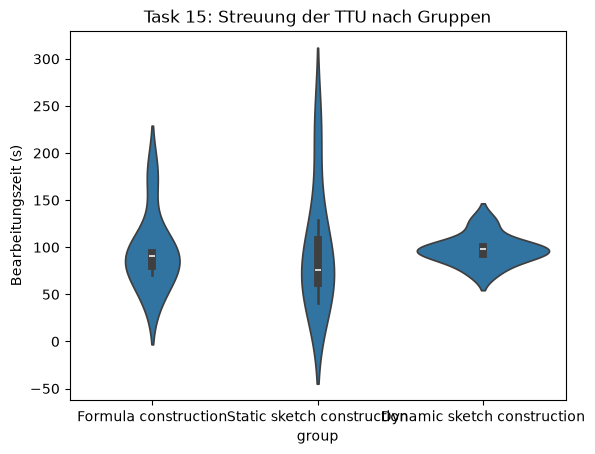

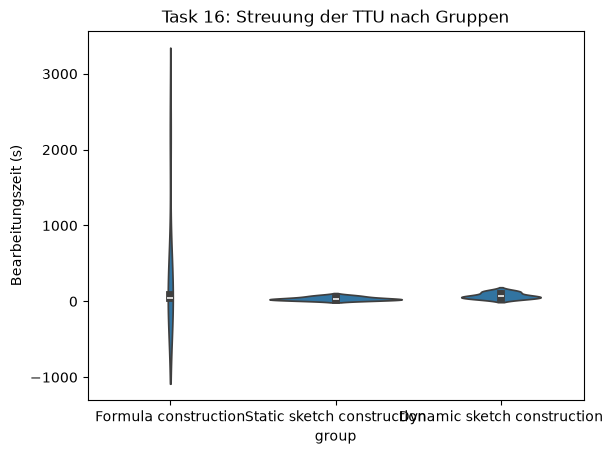

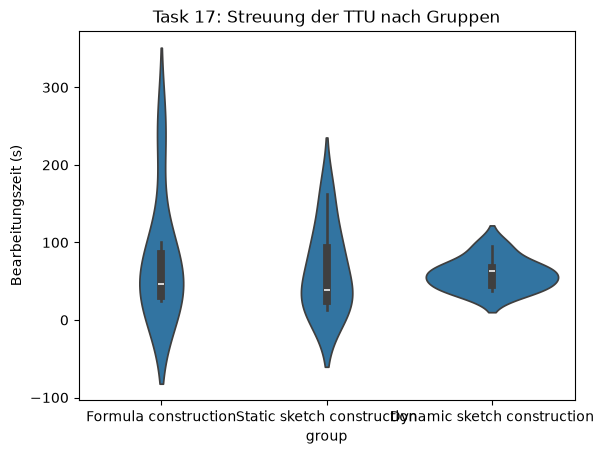

In [9]:
for task_id in range(1,18): 
    violin_plot_per_task(df=df, task_id=task_id)

Nach Anblick der Plots entsteht Vermutung, dass die Streuung bei "dynamic sketch construction" kleiner ist. Daher teste ich nun die Varianzen auf signifikante Unterschiede:

In [10]:
from scipy.stats import levene


def dispersion_differences(df:pd.Dataframe, task_id:int): 
    df_task = df[df["id"] == task_id]
    group_names = df["group"].unique().tolist() 

    groups = [
        df_task[df_task["group"] == name]["TTU"].values
        for name in group_names
    ]
    
    # Levene-Test
    stat, p = levene(*groups)
    
    if p < alpha:
        interpretation = "Significant"  # Varianzen ungleich
    else:
        interpretation = "Not significant"  # Varianzen gleich
    
    # Ausgabe
    print(f"Levene-Test (Task 2): F = {stat:.3f}, p = {p:.4f}")
    print(f"   → {interpretation} (α = {alpha})")
    print(f"   → p < α → Varianzen sind ungleich" if p < alpha else f"   → p ≥ α → Varianzen sind gleich")

In [11]:
for task_id in range(1, 18):
    dispersion_differences(df=df, task_id = task_id)


Levene-Test (Task 2): F = 0.310, p = 0.7369
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 0.147, p = 0.8641
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 2.728, p = 0.0923
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 1.169, p = 0.3332
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 1.101, p = 0.3540
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 0.494, p = 0.6183
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 0.061, p = 0.9414
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 0.435, p = 0.6539
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
Levene-Test (Task 2): F = 0.910, p = 0.4202
   → Not significant (α = 0.05)
   → p ≥ α → Varianzen sind gleich
L

# DOU 
Die DOU_werte sind ordinal skaliert. Daher verwenden wir hier von vorneherein Kruskal-Wallis. 

In [12]:
import warnings

def kruskal_DOU(task_id:int, print_active:bool=False):
    df_task = df[df["id"] == task_id]
    
    # Prüfe, ob alle 3 Gruppen vertreten sind
    if df_task["group"].nunique() < 3:
        if print_active: 
            print(f"Task {task_id}: Nur {df_task['group'].nunique()} Gruppen → übersprungen")
        return None, False
    
    # Prüfe, ob mindestens 2 Teilnehmer pro Gruppe
    group_counts = df_task.groupby("group").size()
    if group_counts.min() < 2:
        if print_active: 
            print(f"Task {task_id}: Mindestens eine Gruppe hat <2 Teilnehmer → übersprungen")
        return None, False

    # Prüfe, ob DOU-Werte alle gleich sind
    if df_task["DOU"].nunique() == 1:
        if print_active: 
            print(f"Task {task_id}: Alle DOU-Werte gleich → Kruskal-Wallis nicht möglich")
        return None, False

    # Fange Warnungen ab
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")  # Fange alle Warnungen
        try:
            kruskal_result = pg.kruskal(data=df_task, dv="DOU", between="group")
            p_kruskal = kruskal_result["p_unc"].iloc[0]
            group_stats = df_task.groupby("group")["DOU"].agg(["median", "std", "count"]).round(3)
            median_dou = group_stats["median"].to_dict()
            significant = p_kruskal < alpha

            # Prüfe, ob Warnungen aufgetreten sind
            if len(w) > 0:
                for warning in w:
                    if "invalid value" in str(warning.message):
                        print(f"Task {task_id}: Warnung: {warning.message}")
                        return None, False
            if print_active: 
                if significant:
                    print(f"Task {task_id}: Kruskal-Wallis (DOU): p = {p_kruskal:.4f}")
                    print(f"   → Mediane (DOU): {median_dou}")
                if not significant: 
                    print(f"Task {task_id}: not significant (Kruskal-Wallis (DOU): p = {p_kruskal:.4f})")
            return df_task, significant

        except Exception as e:
            print(f"Error Task {task_id}: Fehler: {e}")
            return None, False

In [13]:
for task_id in range(1, 18): 
    df_task, significant = kruskal_DOU(task_id=task_id, print_active=True)
    print()

Task 1: not significant (Kruskal-Wallis (DOU): p = 0.1218)

Task 2: not significant (Kruskal-Wallis (DOU): p = 0.3679)

Task 3: not significant (Kruskal-Wallis (DOU): p = 0.3679)

Task 4: Alle DOU-Werte gleich → Kruskal-Wallis nicht möglich

Task 5: not significant (Kruskal-Wallis (DOU): p = 0.6778)

Task 6: not significant (Kruskal-Wallis (DOU): p = 0.0821)

Task 7: not significant (Kruskal-Wallis (DOU): p = 0.1316)

Task 8: Kruskal-Wallis (DOU): p = 0.0313
   → Mediane (DOU): {'Dynamic sketch construction': 1.0, 'Formula construction': 1.0, 'Static sketch construction': 0.857}

Task 9: not significant (Kruskal-Wallis (DOU): p = 0.5107)

Task 10: not significant (Kruskal-Wallis (DOU): p = 0.3865)

Task 11: Alle DOU-Werte gleich → Kruskal-Wallis nicht möglich

Task 12: Alle DOU-Werte gleich → Kruskal-Wallis nicht möglich

Task 13: not significant (Kruskal-Wallis (DOU): p = 0.5908)

Task 14: not significant (Kruskal-Wallis (DOU): p = 0.1006)

Task 15: Kruskal-Wallis (DOU): p = 0.0011
  

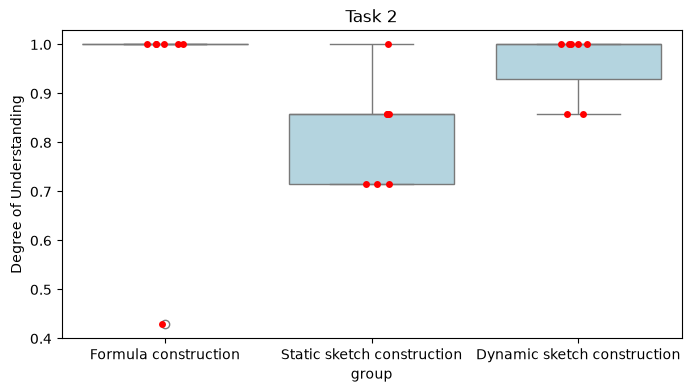

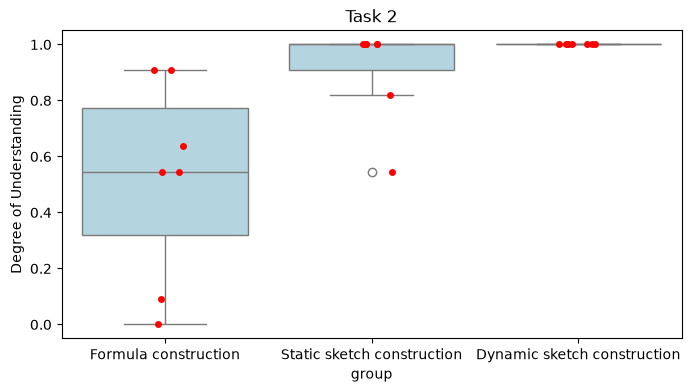

In [14]:
for task_id in range(1, 18): 
    df_task, significant = kruskal_DOU(task_id=task_id, print_active=False)
    if significant: 
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df_task, x="group", y="DOU", color="lightblue")
        sns.stripplot(data=df_task, x="group", y="DOU", color="red", jitter=True)
        plt.title("Task 2")
        plt.ylabel("Degree of Understanding")
        plt.show()
        

-> There are possible significant differences in Task 8 and Task 15. To find out, between which participant groups they are, we need to perform a post-hoc test: 

In [15]:
def posthoc_letter_display(task_id: int, df_task):
    # Post-hoc-Test mit Holm-Korrektur
    posthoc = pg.pairwise_tests(
        data=df_task,
        dv="DOU",
        between="group",
        parametric=False,
        padjust="holm"
    )
    posthoc = posthoc[["A", "B", "p_unc", "p_corr"]].copy()
    posthoc = posthoc[posthoc["p_corr"] < alpha]  # Nur signifikante Paare

    # Kompaktes Letter-Display
    letters = {}
    for group in df_task["group"].unique():
        letters[group] = "a"  # Start mit a

    # Vergleiche Paare
    for _, row in posthoc.iterrows():
        a, b = row["A"], row["B"]
        if row["p_corr"] < alpha:
            if letters[a] == letters[b]:
                pass
            else:
                letters[a] = "".join(sorted(set(letters[a] + letters[b])))
                letters[b] = letters[a]

    # Sortiere Buchstaben
    for group in letters:
        letters[group] = "".join(sorted(set(letters[group])))

    # Ausgabe
    print(f"   → Letter-Display: {letters}")
    return letters

In [16]:
for task_id in range(1, 18): 
    df_task, significant = kruskal_DOU(task_id=task_id, print_active=False)
    if significant: 
        posthoc_letter_display(task_id, df_task)

   → Letter-Display: {'Formula construction': 'a', 'Static sketch construction': 'a', 'Dynamic sketch construction': 'a'}
   → Letter-Display: {'Formula construction': 'a', 'Static sketch construction': 'a', 'Dynamic sketch construction': 'a'}
